# Series resummation on the infinite 2d square lattice

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
import h5py
from robustpade import pade_approx, pade_approx_batch 

## Free energy density as function of chemical potential: $\beta t= 1.0$, $U/t=6$

$-k_BT \ln Z$ as a function of $\mu$. 

In [5]:
U=6.0
beta=1.0

In [6]:
def Z_atomic(U:float, beta:float, mu:float):

    return 1+2*np.exp(beta*mu)+np.exp(beta*(2*mu - U))


def a_0(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)
    return -1/beta*np.log(Zat) # factor 2 for spin and


def a_2(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)

    fact = np.exp(beta*mu)/Zat**2
    A = beta**2/2*(1+np.exp(-beta*(U-2*mu)))
    B = 2*beta/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)
    return -2/beta*fact*(A+B)*4 #factor 2 for spin and 2 for sites!


In [23]:
#load order4
with h5py.File('/Users/louissharma/Desktop/results_sc/results/full_lattice_Omega_order_4_scan_mu_U=6.0_beta=1.0_alpha=0.3.h5', 'r') as f:
    mus = f['mu_list'][:]
    means_4 = f['mean_list'][:]
    errors_4 = f['error_list'][:]

#loard order 6
with h5py.File('/Users/louissharma/Desktop/results_sc/results/full_lattice_Omega_order_6_scan_mu_U=6.0_beta=1.0_alpha=0.3_old.h5', 'r') as f:
    mus_6 = f['mu_list'][:]
    means_6 = f['mean_list'][:]
    errors_6 = f['error_list'][:]

In [24]:
a4 = means_4
a6 = means_6

In [28]:
a6.shape

(48,)

In [29]:
t = 0.9
g = t**2
coeffs_sq = np.array([a_0(U, beta, mus), a_2(U, beta, mus),a4, a6]) #treat as a function of t^2

orders = {(2,1): [], (1,2): []}
for order in orders.keys():
    pade_sum = pade_approx_batch(coeffs_sq, order, 0.0)(t**2).real
    orders[order].append(pade_sum)

naive_sum_6 = lambda g: a_0(U,beta, mus) + a_2(U, beta, mus)*g + a4*g**2 + a6*g**3

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

ValueError: operands could not be broadcast together with shapes (50,) (48,) 

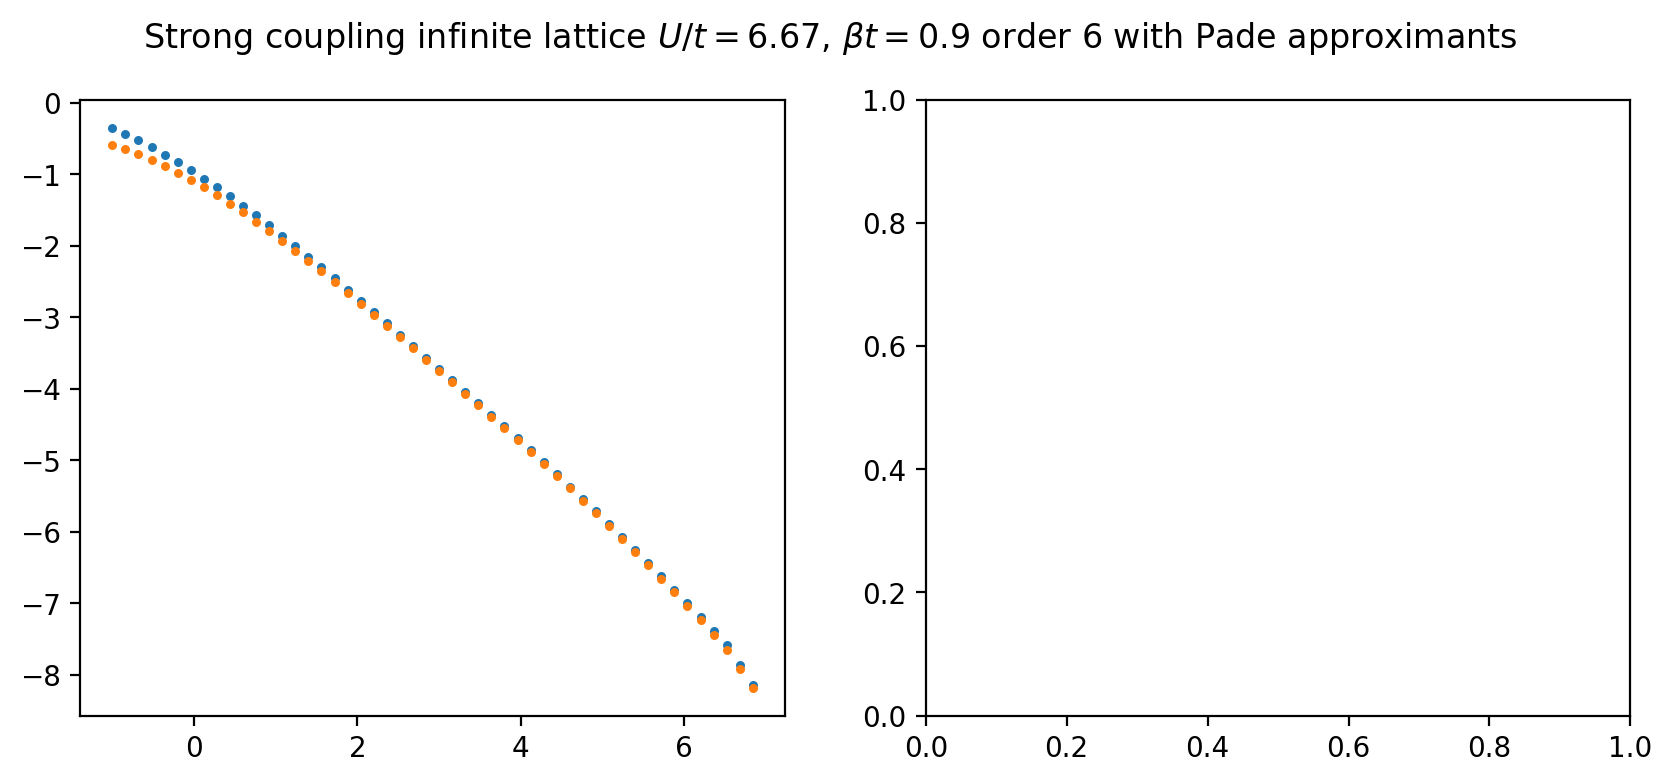

In [30]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

fig.suptitle(rf'Strong coupling infinite lattice $U/t={ U/t:.2f}$, $\beta t={beta*t}$ order 6 with Pade approximants')
for order in orders.keys():
    ax1.scatter(mus, orders[order][0], label=f'Pade {order}', s=5)

ax1.scatter(mus, naive_sum_6(1.0), label='order 6 sum', s=5, c='k')

ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel('Free energy density')
ax1.legend()

for order in orders.keys():
    ax2.scatter(mus, -np.gradient(orders[order][0], mus), label=f'Pade {order}', s=5)

ax2.scatter(mus, -np.gradient(naive_sum_6(g), mus), label='order 6 sum', s=5, c='k')
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel('Density')

ax2.plot(mus, -np.gradient(a_0(U, beta, mus), mus), label='atomic limit', c='r', linestyle='dashed')
ax2.legend()